First, we have to import packages and load our data!

Kaggle has an API option, but its honestly just easier to download the file b/c its not too big

Sources:

Election dataset: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/VOQCHQ 

Storms dataset: https://www.kaggle.com/datasets/brsdincer/natural-disaster-data-noaa-years 


In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import glob
import os
import re
import string
import plotnine
from plotnine import *
import matplotlib




## sklearn imports from class for binary outputs j in case
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

## print mult things
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

Loading storms data is complicated: we have to read in a file for each year and then combine them all into one df

In [2]:

folder = "storm_data"

csv_files = glob.glob(os.path.join(folder, "StormEvents_details-ftp_v1.0_*.csv"))

print("Found files:", csv_files)

dfs = []

for file in csv_files:   #this is from chatgpt, didn't learn it in class and I didnt want to do it manually
    print("Reading file:", file)
    df = pd.read_csv(file)
    if not df.empty:
        # Extract year from filename using regex
        match = re.search(r'd(\d{4})', os.path.basename(file))
        if match:
            year = int(match.group(1))
            df['year'] = year
            dfs.append(df)
        else:
            print("Year not found in filename:", file)
    else:
        print("Skipped empty file:", file)


storms = pd.concat(dfs, ignore_index=True)

print("Combined DataFrame shape:", storms.shape)
print("Years in data:", storms['year'].unique())

Found files: ['storm_data/StormEvents_details-ftp_v1.0_d2001_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2024_c20250818.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2012_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2005_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2002_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2006_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2011_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2008_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2020_c20250702.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2022_c20250721.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2018_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2021_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2023_c20250731.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2016_c20250818.csv', 'storm_data/StormEvents_details-ftp_v1.0_d2019_c20250520.csv', 'storm_data/StormEvents_details-ftp_v1.0_

Loading Election data is much more simple, and we filter our storms data to just include counties

In [3]:
elections = pd.read_csv("election_data/countypres_2000-2024.csv")

#only select storms that occured in counties 

storms_counties = storms[storms["CZ_TYPE"] == "C"]

#check to make sure
#print(storms_counties["CZ_TYPE"].value_counts())



Now, we have to deal with crop and property damage values: they are currently not in integer format and have to be handled with precision otherwise, we will incorporate incorrect inforamtion

We will also visualize the distribution of storm damage

DAMAGE_PROPERTY
0.00K      350961
1.00K       28682
5.00K       27058
10.00K      22204
2.00K       21397
            ...  
703.42K         1
99.23K          1
71.90K          1
44.69K          1
22.7M           1
Name: count, Length: 2179, dtype: int64
property_damage_numeric
0         626080
5000       36058
1000       33996
10000      29407
2000       27231
           ...  
7400           1
791000         1
9600           1
925000         1
14600          1
Name: count, Length: 1666, dtype: int64
16        0
17    50000
18        0
20     2000
22    25000
Name: property_damage_numeric, dtype: int64
16      0
17    50K
18      0
20     2K
22    25K
Name: DAMAGE_PROPERTY, dtype: object
                                  mean  median
Type_of_Damage                                
crop_damage_numeric       14338.674550     0.0
property_damage_numeric  229593.314509     0.0
                                  mean   median
Type_of_Damage                                 
crop_damage_numeric 

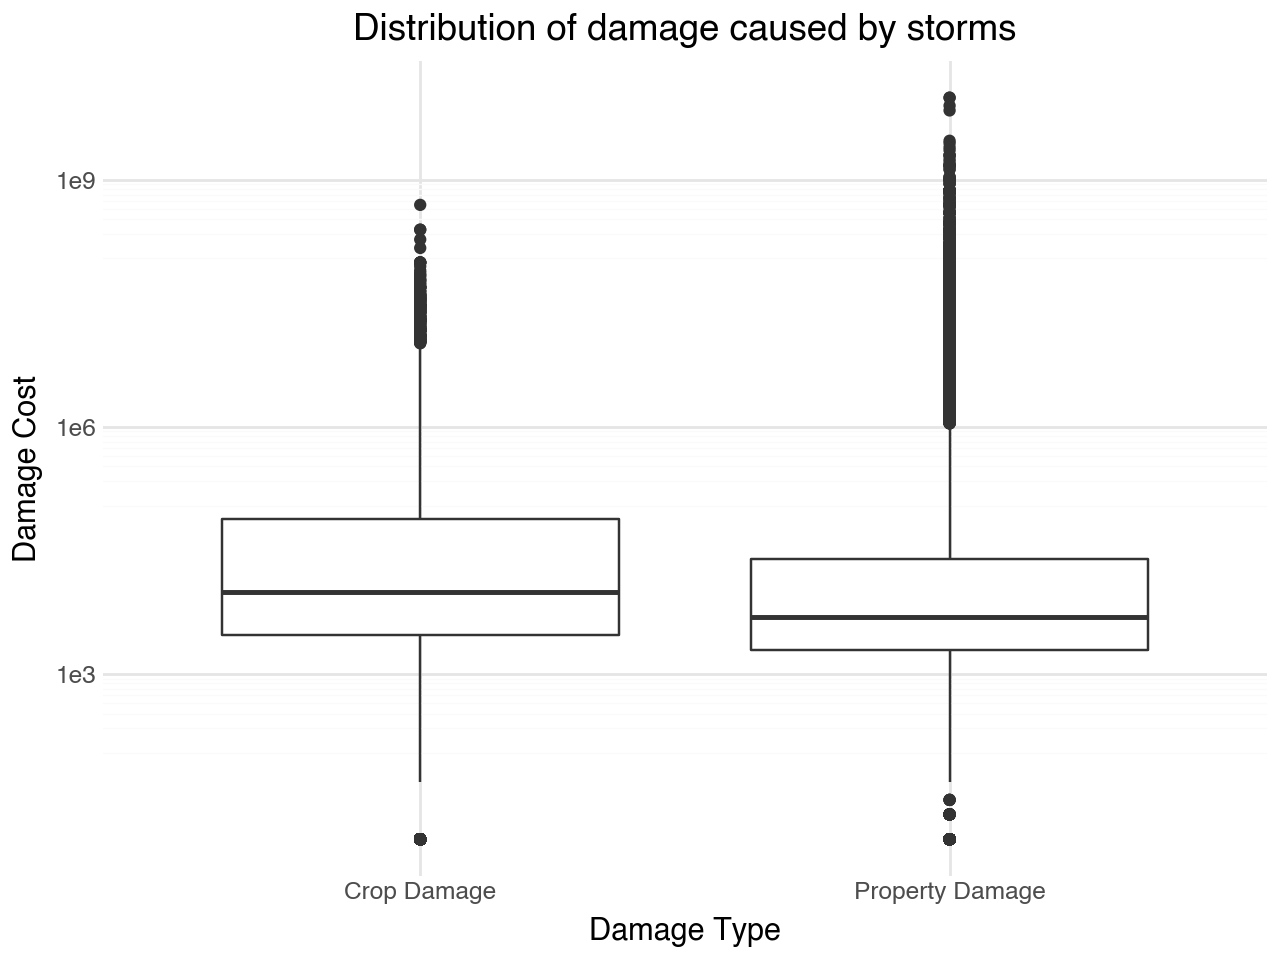

In [4]:
print(storms_counties["DAMAGE_PROPERTY"].value_counts())
#See the K vs. M

#we have to do this for two columns so may as well define a function

def damage_as_num(value):
    if pd.isna(value):
        return 0
    
    value = str(value).strip().upper()
    
    match = re.match(r'^([\d\.]+)\s*([KMB]?)$', value) #regex helped out by gpt, couldn't quite get it right 
    if not match:
        return 0 #choosing to turn NAs into 0s
    
    number, suffix = match.groups() #extract tuple from match group
    number = float(number)
    multiplier = {'K': 1000, 'M': 1000000, 'B': 1000000000}.get(suffix, 1) #dictionary for multiplier, match them to tuple
    
    return number * multiplier


storms_counties["property_damage_numeric"] = storms_counties['DAMAGE_PROPERTY'].apply(damage_as_num).astype(int)

#couple of checks
print(storms_counties["property_damage_numeric"].value_counts())

print(storms_counties["property_damage_numeric"].head())

print(storms_counties["DAMAGE_PROPERTY"].head())



storms_counties["crop_damage_numeric"] = storms_counties['DAMAGE_CROPS'].apply(damage_as_num).astype(int)


#lets visualize the costs using a boxplot

df_damage_vis = pd.melt(storms_counties,
                        value_vars=['property_damage_numeric', 'crop_damage_numeric'],
                        var_name= "Type_of_Damage",
                        value_name= "Value")


print(df_damage_vis.groupby("Type_of_Damage")["Value"].agg(["mean", "median"])) 

#We notice the zeros are really skewing our data. We want to focus on high-impact storms so we will drop rows with a value of zero
#in our visualization and statline, then do it for the parent dataframe further down

df_damage_vis_clean = df_damage_vis[df_damage_vis["Value"] > 0]

#HUGE difference


print(df_damage_vis_clean.groupby("Type_of_Damage")["Value"].agg(["mean", "median"])) 

plot = (
    ggplot(df_damage_vis_clean, aes(x='Type_of_Damage', y='Value'))
    + geom_boxplot()
    + scale_y_log10()
    + scale_x_discrete(labels= ["Crop Damage", "Property Damage"])  
    + labs(
        title="Distribution of damage caused by storms",
        x="Damage Type",
        y="Damage Cost"
    )
    + theme_minimal()
)

plot

storm_counties_nozerodmg = storms_counties[storms_counties["property_damage_numeric"] > 0]
storm_counties_nozerodmg = storm_counties_nozerodmg[storm_counties_nozerodmg["crop_damage_numeric"] > 0]


Now, lets clean up our election data to get the variable we want

In [5]:
df_dem = elections.loc[elections['party'] == 'DEMOCRAT'].copy()

df_dem["percent"] = df_dem['candidatevotes'] / df_dem['totalvotes']



df_dem = df_dem[['year', 'state', 'county_fips', 'county_name', 'percent']]
df_dem = df_dem.sort_values(['county_fips', 'year'])

# Compute change from previous election (diff within each county)
df_dem['change_in_dem_vote_percent'] = df_dem.groupby('county_fips')['percent'].diff()


print(df_dem.head(10))


       year    state  county_fips county_name   percent  \
0      2000  ALABAMA       1001.0     AUTAUGA  0.287192   
12629  2004  ALABAMA       1001.0     AUTAUGA  0.236940   
22102  2008  ALABAMA       1001.0     AUTAUGA  0.257730   
31576  2012  ALABAMA       1001.0     AUTAUGA  0.265878   
41051  2016  ALABAMA       1001.0     AUTAUGA  0.237697   
50525  2020  ALABAMA       1001.0     AUTAUGA  0.270184   
72619  2024  ALABAMA       1001.0     AUTAUGA  0.263039   
4      2000  ALABAMA       1003.0     BALDWIN  0.247822   
12632  2004  ALABAMA       1003.0     BALDWIN  0.225029   
22105  2008  ALABAMA       1003.0     BALDWIN  0.238119   

       change_in_dem_vote_percent  
0                             NaN  
12629                   -0.050252  
22102                    0.020790  
31576                    0.008148  
41051                   -0.028182  
50525                    0.032487  
72619                   -0.007145  
4                             NaN  
12632                   -0

It gets tricky here. I think the next move is to split the elections dataset by year, and match the storms dataset in the same way

We will also create a column to merge on, namely the county_fips column. this has to be manually created for the storms dataset, and cleaned for the MIT dataset

In [ ]:

df_dem["county_fips_cleaned"] = df_dem['county_fips'].astype(str)


df_dem['county_fips_cleaned'] = df_dem['county_fips_cleaned'].str.replace(r'\.0$', '', regex=True)

#zero padding from stack
df_dem['county_fips_cleaned'] = df_dem['county_fips_cleaned'].str.zfill(5)

print(df_dem[['county_fips_cleaned']].head())


df_dem = df_dem[df_dem["year"] > 2000]

years = df_dem['year'].unique()


dfs_by_year = {year: df_dem[df_dem['year'] == year].copy() for year in years}


df_2004 = dfs_by_year[2004]
df_2008 = dfs_by_year[2008]
df_2012 = dfs_by_year[2012]
df_2016 = dfs_by_year[2016]
df_2020 = dfs_by_year[2020]
df_2024 = dfs_by_year[2024]

#For storms, its a bit more tricky, we have to group by election year, not just the year, so we use the yearmonth, and day column to parse out a date

#function to parse
def parse_year_month(value):
    match = re.match(r'(\d{4})(\d{2})', str(value))
    if match:
        year, month = match.groups()
        return int(year), int(month)
    else:
        return None, None
    


storm_counties_nozerodmg[["year", "month"]] = storm_counties_nozerodmg["BEGIN_YEARMONTH"].apply(lambda x: pd.Series(parse_year_month(x))) #ending bit is form gpt cuz i couldn't extract a tuple into 2 columns

storm_counties_nozerodmg["day"] = storm_counties_nozerodmg["BEGIN_DAY"]

storm_counties_nozerodmg["date"] = pd.to_datetime(storm_counties_nozerodmg[["year", "month", "day"]])


#Adding in cleaned county FIPS here, before we move on to grouping them

print(storm_counties_nozerodmg[['CZ_FIPS', "STATE_FIPS"]]) #stored as a string which is annoying
storm_counties_nozerodmg['STATE_FIPS'] = storm_counties_nozerodmg['STATE_FIPS'].astype(str)

storm_counties_nozerodmg['STATE_FIPS'] = (
    storm_counties_nozerodmg['STATE_FIPS']
    .str.replace(r'\.0$', '', regex=True)  
    .astype(int)                           
    .astype(str)                           
    .str.zfill(2)     
                      )                   
storm_counties_nozerodmg['STATE_FIPS'] = storm_counties_nozerodmg['STATE_FIPS'].astype(int)
storm_counties_nozerodmg['STATE_FIPS'] = storm_counties_nozerodmg['STATE_FIPS'].astype(str).str.zfill(2) #zero padding here and below just in case tbh
storm_counties_nozerodmg['CZ_FIPS'] = storm_counties_nozerodmg['CZ_FIPS'].astype(str).str.zfill(3)
storm_counties_nozerodmg['county_fips'] = storm_counties_nozerodmg['STATE_FIPS'] + storm_counties_nozerodmg['CZ_FIPS']

print(storm_counties_nozerodmg["county_fips"])




storms_2004 = storm_counties_nozerodmg[storm_counties_nozerodmg["date"] < '2004-11-02']

storms_2008 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2004-11-02') & (storm_counties_nozerodmg["date"] < '2008-11-04')]

storms_2012 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2008-11-04') & (storm_counties_nozerodmg["date"] < '2012-11-06')]

storms_2016 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2012-11-06') & (storm_counties_nozerodmg["date"] < '2016-11-08')]

storms_2020 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2016-11-08') & (storm_counties_nozerodmg["date"] < '2020-11-03')]

storms_2024 = storm_counties_nozerodmg[(storm_counties_nozerodmg["date"] > '2020-11-03') & (storm_counties_nozerodmg["date"] < '2024-11-05')]















      county_fips_cleaned
0                   01001
12629               01001
22102               01001
31576               01001
41051               01001
         CZ_FIPS  STATE_FIPS
140            1        49.0
144           35        49.0
1258          45        49.0
1534          49        49.0
3887         115        47.0
...          ...         ...
1519402       39        49.0
1519534       53        49.0
1519535       11        49.0
1519536       29        49.0
1519612       89        47.0

[15105 rows x 2 columns]
140        49001
144        49035
1258       49045
1534       49049
3887       47115
           ...  
1519402    49039
1519534    49053
1519535    49011
1519536    49029
1519612    47089
Name: county_fips, Length: 15105, dtype: object


We will merge each dataset to begin our initial visualization of first just tracking aggregate storm damage per county versus change in democratic votes

        BEGIN_YEARMONTH  BEGIN_DAY  BEGIN_TIME  END_YEARMONTH  END_DAY  \
187524           200501          7           0         200501       11   
188971           200501         12        2240         200501       12   
192108           200504         17        1530         200504       17   
193667           200504         17        1535         200504       17   
195934           200505         17        1457         200505       17   

        END_TIME  EPISODE_ID  EVENT_ID       STATE STATE_FIPS  ...  \
187524      2300     1184791   5436692  CALIFORNIA         06  ...   
188971      2240     1184634   5438445    MICHIGAN         26  ...   
192108      1710     1186577   5445590  NEW MEXICO         35  ...   
193667      1600     1186577   5445493  NEW MEXICO         35  ...   
195934      1457     1188720   5446975    NEBRASKA         31  ...   

                                        EPISODE_NARRATIVE  \
187524  A storm lasting 5 days dropped heavy rain acro...   
188971      

Text(0.5, 1.1, 'Aggregate Property damage vs. change in democratic vote %')

Text(0.5, -0.05, 'Aggregate property damage per county')

Text(-0.05, 0.5, 'change in democratic vote %')

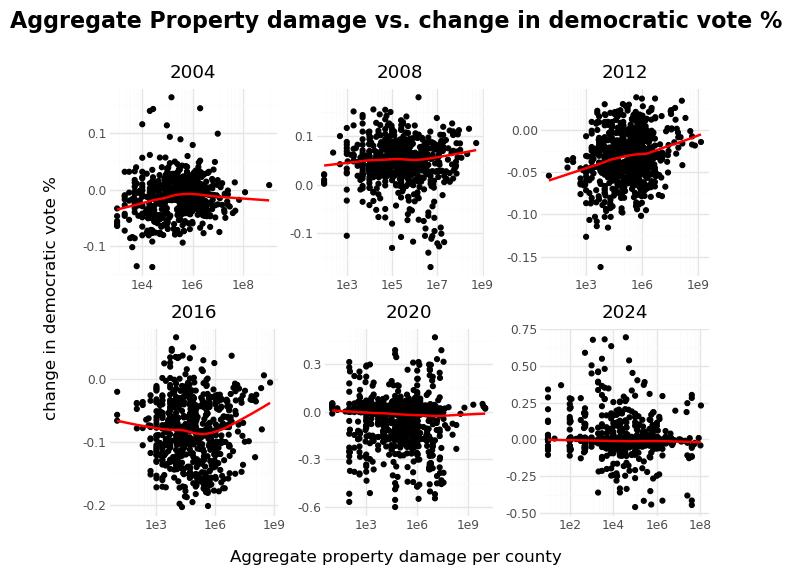

In [7]:

storms_prop_agg_2004 = storms_2004.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2008 = storms_2008.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2012 = storms_2012.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2016 = storms_2016.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2020 = storms_2020.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()
storms_prop_agg_2024 = storms_2024.groupby('county_fips', as_index=False)['property_damage_numeric'].sum()

print(storms_2008.head())
print(storms_prop_agg_2012.head())



def merge_storms_elections(storms, elections):
    df_merged = pd.merge(
        storms,
        elections,
        how= "inner",
        left_on= "county_fips",
        right_on= "county_fips_cleaned"
    )
    
    return df_merged


property_damage_2004 = merge_storms_elections(storms_prop_agg_2004, df_2004)
property_damage_2008 = merge_storms_elections(storms_prop_agg_2008, df_2008)
property_damage_2012 = merge_storms_elections(storms_prop_agg_2012, df_2012)
property_damage_2016 = merge_storms_elections(storms_prop_agg_2016, df_2016)
property_damage_2020 = merge_storms_elections(storms_prop_agg_2020, df_2020)
property_damage_2024 = merge_storms_elections(storms_prop_agg_2024, df_2024)


print(property_damage_2008.head())


def initial_plot_function(df, year=2004):
   
    df_filt = df[df["property_damage_numeric"] > 0]
    plot = (
    ggplot(df_filt, aes(x = "property_damage_numeric", y = "change_in_dem_vote_percent")) +
    geom_point() +
    geom_smooth(color = "red") +
    scale_x_log10() +
    labs(title = f'{year}',
         x= '',
         y= '') +
    theme_minimal()
)
    return plot

plot_2004 = initial_plot_function(property_damage_2004)
plot_2008 = initial_plot_function(property_damage_2008, 2008)
plot_2012 = initial_plot_function(property_damage_2012, 2012)
plot_2016 = initial_plot_function(property_damage_2016, 2016)
plot_2020 = initial_plot_function(property_damage_2020, 2020)
plot_2024 = initial_plot_function(property_damage_2024, 2024)
combined_property_plot = (plot_2004 | plot_2008 | plot_2012)/(plot_2016 | plot_2020 | plot_2024)

fig = combined_property_plot.draw()  # render the patchwork layout
fig.suptitle("Aggregate Property damage vs. change in democratic vote %", fontsize=16, fontweight='bold', y=1.1)

fig.text(0.5, -.05, "Aggregate property damage per county", ha='center', fontsize=12)  # X-axis
fig.text(-0.05, 0.5, "change in democratic vote %", va='center', rotation='vertical', fontsize=12)  # Y-axis

fig



Repeat prelim analysis for crop damage

  county_fips_x  crop_damage_numeric  year     state  county_fips_y  \
0         01025              3000000  2012   ALABAMA         1025.0   
1         04023                75000  2012   ARIZONA         4023.0   
2         05001             12150000  2012  ARKANSAS         5001.0   
3         05003               650000  2012  ARKANSAS         5003.0   
4         05005               250000  2012  ARKANSAS         5005.0   

  county_name   percent  change_in_dem_vote_percent county_fips_cleaned  
0      CLARKE  0.457296                    0.017102               01025  
1  SANTA CRUZ  0.682741                    0.030031               04023  
2    ARKANSAS  0.378041                    0.002719               05001  
3      ASHLEY  0.360939                    0.016575               05003  
4      BAXTER  0.267439                   -0.059822               05005  


Text(0.5, 1.1, 'Aggregate Crop damage vs. change in democratic vote %')

Text(0.5, -0.05, 'Aggregate crop damage per county')

Text(-0.05, 0.5, 'change in democratic vote %')

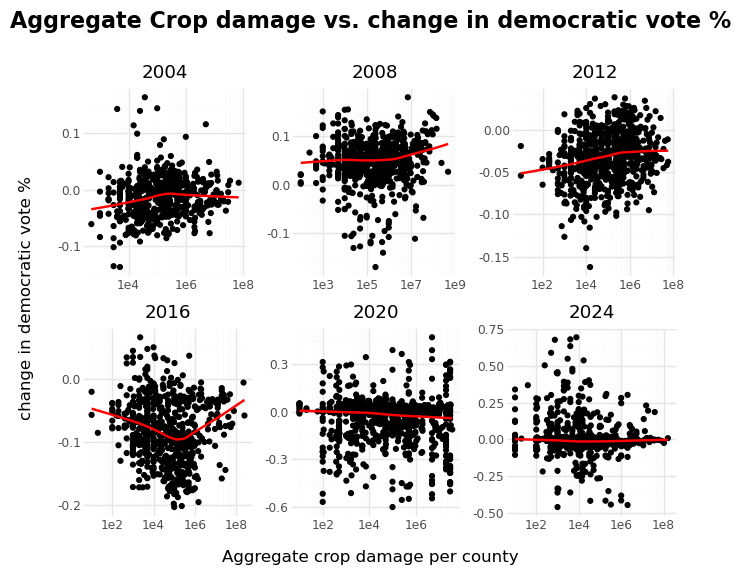

In [8]:

#aggregate on crops
crops_2004 = storms_2004.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2008 = storms_2008.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2012 = storms_2012.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2016 = storms_2016.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2020 = storms_2020.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()
crops_2024 = storms_2024.groupby('county_fips', as_index=False)['crop_damage_numeric'].sum()


#merge
crops_merged_2004 = merge_storms_elections(crops_2004, df_2004)
crops_merged_2008 = merge_storms_elections(crops_2008, df_2008)
crops_merged_2012 = merge_storms_elections(crops_2012, df_2012)
crops_merged_2016 = merge_storms_elections(crops_2016, df_2016)
crops_merged_2020 = merge_storms_elections(crops_2020, df_2020)
crops_merged_2024 = merge_storms_elections(crops_2024, df_2024)

print(crops_merged_2012.head())

#new function to make crop figures
def initial_plot_function_2(df, year=2004):
   
    df_filt = df[df["crop_damage_numeric"] > 0]
    plot = (
    ggplot(df_filt, aes(x = "crop_damage_numeric", y = "change_in_dem_vote_percent")) +
    geom_point() +
    geom_smooth(color = "red") +
    scale_x_log10() +
    labs(title = f"{year}",
         x= '',
         y= '') +
    theme_minimal()
)
    return plot

crop_plot_2004 = initial_plot_function_2(crops_merged_2004) 

crop_plot_2008 = initial_plot_function_2(crops_merged_2008, 2008)

crop_plot_2012 = initial_plot_function_2(crops_merged_2012, 2012)

crop_plot_2016 = initial_plot_function_2(crops_merged_2016, 2016)

crop_plot_2020 = initial_plot_function_2(crops_merged_2020, 2020)

crop_plot_2024 = initial_plot_function_2(crops_merged_2024, 2024)



combined_crop_plot = (crop_plot_2004 | crop_plot_2008 | crop_plot_2012)/(crop_plot_2016 | crop_plot_2020 | crop_plot_2024)



fig2 = combined_crop_plot.draw()  # render the patchwork layout
fig2.suptitle("Aggregate Crop damage vs. change in democratic vote %", fontsize=16, fontweight='bold', y=1.1)

fig2.text(0.5, -.05, "Aggregate crop damage per county", ha='center', fontsize=12)  # X-axis
fig2.text(-0.05, 0.5, "change in democratic vote %", va='center', rotation='vertical', fontsize=12)  # Y-axis

fig2



And finally, we look at the number of deaths aggregated per county as our final preliminary analysis

Text(0.5, 1.1, 'Aggregate deaths per county vs. change in democratic vote %')

Text(0.5, -0.05, 'Aggregate deaths per county')

Text(-0.05, 0.5, 'change in democratic vote %')

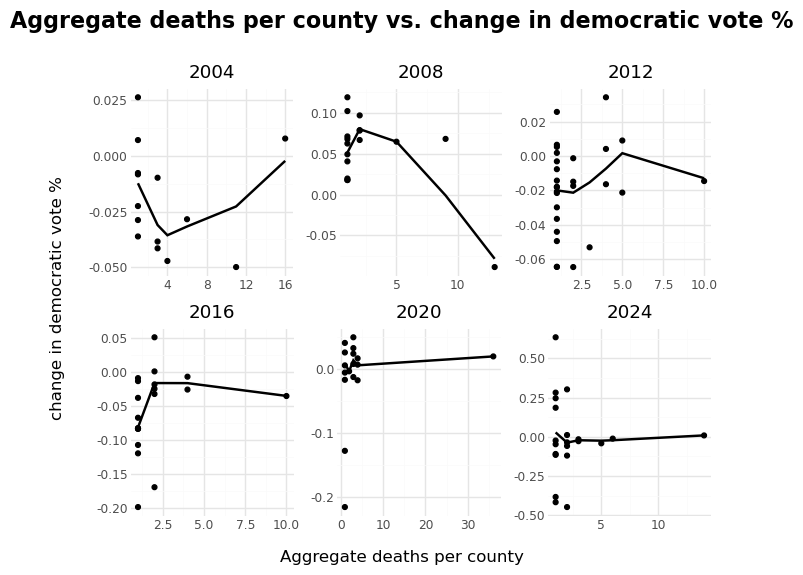

In [9]:
deaths_2004 = storms_2004.groupby('county_fips', as_index=False)['DEATHS_DIRECT'].sum()
deaths_2008 = storms_2008.groupby('county_fips', as_index=False)['DEATHS_DIRECT'].sum()
deaths_2012 = storms_2012.groupby('county_fips', as_index=False)['DEATHS_DIRECT'].sum()
deaths_2016 = storms_2016.groupby('county_fips', as_index=False)['DEATHS_DIRECT'].sum()
deaths_2020 = storms_2020.groupby('county_fips', as_index=False)['DEATHS_DIRECT'].sum()
deaths_2024 = storms_2024.groupby('county_fips', as_index=False)['DEATHS_DIRECT'].sum()

deaths_merged_2004 = merge_storms_elections(deaths_2004, df_2004)
deaths_merged_2008 = merge_storms_elections(deaths_2008, df_2008)
deaths_merged_2012 = merge_storms_elections(deaths_2012, df_2012)
deaths_merged_2016 = merge_storms_elections(deaths_2016, df_2016)
deaths_merged_2020 = merge_storms_elections(deaths_2020, df_2020)
deaths_merged_2024 = merge_storms_elections(deaths_2024, df_2024)




def initial_plot_function_3(df, year=2004):
   
    df_filt = df[df["DEATHS_DIRECT"] > 0]
    df_labels = df_filt[df_filt["DEATHS_DIRECT"] > 10]
    plot = (
    ggplot(df_filt, aes(x = "DEATHS_DIRECT", y = "change_in_dem_vote_percent")) +
    geom_point() +
    geom_smooth() +
    labs(title = f"{year}",
         x="",
         y='') +
    theme_minimal()
)
    return plot


deaths_plot_2004 = initial_plot_function_3(deaths_merged_2004) 

deaths_plot_2008 = initial_plot_function_3(deaths_merged_2008, 2008)

deaths_plot_2012 = initial_plot_function_3(deaths_merged_2012, 2012)

deaths_plot_2016 = initial_plot_function_3(deaths_merged_2016, 2016)

deaths_plot_2020 = initial_plot_function_3(deaths_merged_2020, 2020)

deaths_plot_2024 = initial_plot_function_3(deaths_merged_2024, 2024)

combined_death_plot = (deaths_plot_2004 | deaths_plot_2008 | deaths_plot_2012)/(deaths_plot_2016 | deaths_plot_2020 | deaths_plot_2024)



fig3 = combined_death_plot.draw()  # render the patchwork layout
fig3.suptitle("Aggregate deaths per county vs. change in democratic vote %", fontsize=16, fontweight='bold', y=1.1)

fig3.text(0.5, -.05, "Aggregate deaths per county", ha='center', fontsize=12)  
fig3.text(-0.05, 0.5, "change in democratic vote %", va='center', rotation='vertical', fontsize=12)  

fig3

No big hits there....
I want to see if certain events have more of an effect than others. One way to look at this is to see if there is an increase in voter%change if tornado intensity increases

['F0' 'F1' 'F2' 'F3' 'EF0' 'EF1' 'EF2' 'EF3' 'EF4' 'EF5' 'EFU' 'F4']
['EF0' 'EF1' 'EF2' 'EF3' 'EF4' 'EF5' 'EFU']
       BEGIN_YEARMONTH  BEGIN_DAY  BEGIN_TIME  END_YEARMONTH  END_DAY  \
14372           200106         12        2046         200106       12   
17768           200106          1        1512         200106        1   
20695           200106         14        1545         200106       14   
22551           200105         21        1630         200105       21   
22686           200105         21        1320         200105       21   

       END_TIME  EPISODE_ID  EVENT_ID     STATE STATE_FIPS  ...  \
14372      2046     1114437   5243399  NEBRASKA         31  ...   
17768      1525     1115354   5246514      IOWA         19  ...   
20695      1545     1115361   5246703      IOWA         19  ...   
22551      1631     1116252   5251200  MICHIGAN         26  ...   
22686      1325     1116252   5251062  MICHIGAN         26  ...   

                                         EVEN

Text(0.5, 1.1, 'The average change in democratic vote % across tornado strengths')

Text(0.5, -0.05, 'Tornado strength')

Text(-0.05, 0.5, 'average change in democratic vote %')

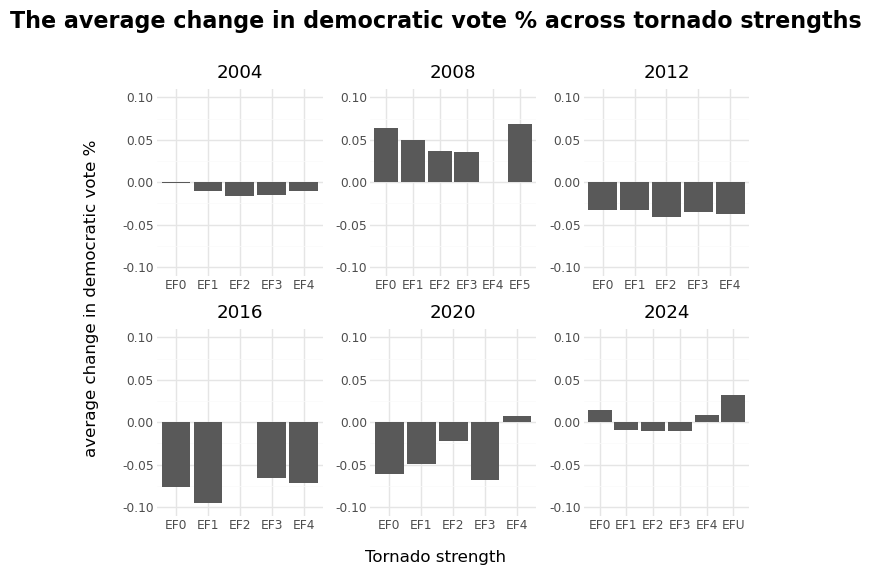

In [15]:
tornadoes_only = storm_counties_nozerodmg[storm_counties_nozerodmg["EVENT_TYPE"] == 'Tornado']

#notice that tornadoe scale is not standardized, they are mixed
print(tornadoes_only["TOR_F_SCALE"].unique())

tornadoes_only["tor_scale"] = tornadoes_only["TOR_F_SCALE"].astype(str).replace(
    to_replace=r"^F(?!F)",  
    value="EF",
    regex=True)

print(tornadoes_only["tor_scale"].unique())

tornadoes_2004 = tornadoes_only[tornadoes_only["date"] < '2004-11-02']
tornadoes_2008 = tornadoes_only[(tornadoes_only["date"] > '2004-11-02') & (tornadoes_only["date"] < '2008-11-04')]
tornadoes_2012 = tornadoes_only[(tornadoes_only["date"] > '2008-11-04') & (tornadoes_only["date"] < '2012-11-06')]
tornadoes_2016 = tornadoes_only[(tornadoes_only["date"] > '2012-11-06') & (tornadoes_only["date"] < '2016-11-08')]
tornadoes_2020 = tornadoes_only[(tornadoes_only["date"] > '2016-11-08') & (tornadoes_only["date"] < '2020-11-03')]
tornadoes_2024 = tornadoes_only[(tornadoes_only["date"] > '2020-11-03') & (tornadoes_only["date"] < '2024-11-05')]

print(tornadoes_2004.head())
print(df_2004.head())


def tornado_plotting_function(tornado, elections, year=2004):
    df_merged = pd.merge(
        tornado,
        elections,
        how= "left",
        left_on= "county_fips",
        right_on= "county_fips_cleaned"
    )

    #aggregate to avg % change

    df_agg = df_merged.groupby("tor_scale")["change_in_dem_vote_percent"].agg("mean").reset_index()

    plot = (
        ggplot(df_agg, aes(x= "tor_scale", y= "change_in_dem_vote_percent")) +
        geom_bar(stat = "identity") +
        labs(y = "", x = "", title = f'{year}') +
        scale_y_continuous(limits=[-0.1, 0.1]) +
        theme_minimal()
    )

    return plot


tornado_plot_2004 = tornado_plotting_function(tornadoes_2004, df_2004)
tornado_plot_2008 = tornado_plotting_function(tornadoes_2008, df_2008, 2008)
tornado_plot_2012 = tornado_plotting_function(tornadoes_2004, df_2012, 2012)
tornado_plot_2016 = tornado_plotting_function(tornadoes_2016, df_2016, 2016)
tornado_plot_2020= tornado_plotting_function(tornadoes_2020, df_2020, 2020)
tornado_plot_2024 = tornado_plotting_function(tornadoes_2024, df_2024, 2024)

combined_tornado_plot = (tornado_plot_2004 | tornado_plot_2008 | tornado_plot_2012)/(tornado_plot_2016 | tornado_plot_2020 | tornado_plot_2024)

fig3 = combined_tornado_plot.draw()  # render the patchwork layout
fig3.suptitle("The average change in democratic vote % across tornado strengths", fontsize=16, fontweight='bold', y=1.1)

fig3.text(0.5, -.05, "Tornado strength", ha='center', fontsize=12)  # X-axis
fig3.text(-0.05, 0.5, "average change in democratic vote %", va='center', rotation='vertical', fontsize=12)  # Y-axis

fig3




Lets see if this is feasible for hurricanes as well, given that they are reported in NWS codes instead of county codes

In [ ]:
hurricanes_only = storms[storms["EVENT_TYPE"] == "Hurricane (Typhoon)"]

#Okay so we found an NWS to county correlation file, lets bring it in 

nws_to_county = pd.read_csv("nws_county_correlation.dbx", sep="|", dtype=str)
nws_to_county.head()

#we should manually add column names to this for clear organization

nws_to_county.columns = [
    "state_abbr",        # e.g. NM
    "zone_number",       # numeric zone ID (e.g. 201)
    "wfo",               # Weather Forecast Office (e.g. ABQ)
    "zone_name",         # e.g. Northwest Plateau
    "zone_code",         # full code like NM201
    "county_name",       # e.g. McKinley
    "county_fips",       # e.g. 35031
    "region_code",       # sometimes 'M' (mountain), 'E', etc.
    "climate_region",    # e.g. 'nw' (northwest)
    "latitude",          # e.g. 36.4270
    "longitude"          # e.g. -108.4064
]

nws_to_county.head()

#zero pad our cz_fips to 3 digit numbers so we can link

hurricanes_only['zone_number'] = hurricanes_only['CZ_FIPS'].astype(str).str.zfill(3)
print(hurricanes_only["zone_number"].value_counts())

hurricanes_only.head()

#This file doesn't work to link the two and all other resources I could find online also aren't a clean match. The same zone applies to multiple counties, so it wouldn't 
#be possible to link the two datasets accurately without getting into the weeds of geometrical data, which I don't have the time to figure out tbh




We can also look at change in % voting for the incumbent, and not just dem percent, so lets set that up and see if we can get an easier workflow/better function

In [ ]:
#create incumbent party column using map function #BOOOM throwback to pset1

incumbent_party = {
    2000: 'Democrat',   
    2004: 'Republican', 
    2008: 'Republican',
    2012: 'Democrat',
    2016: 'Democrat',
    2020: 'Republican',
    2024: 'Democrat'
}

elections_incumb = elections

elections_incumb["incumbent_party"] = elections_incumb['year'].map(incumbent_party)

elections_incumb["vote_percent"] = (elections_incumb["candidatevotes"]/elections_incumb["totalvotes"]) * 100


#want to separate into just the incumbent party now
incumbent_votes = (
    elections_incumb.loc[elections_incumb['party'].str.lower() == elections_incumb['incumbent_party'].str.lower()]
    .copy())

#same strat as last time in sorting and taking diff w prior rows within the groups
incumbent_votes = incumbent_votes.sort_values(['county_fips', 'year'])
incumbent_votes['incumbent_vote_change'] = (incumbent_votes.groupby('county_fips')['vote_percent'].diff())

print(incumbent_votes.head(7))

#clean up county fips for merging as we did prior, prolly could make this a function but its only done twice so shrug
incumbent_votes["county_fips_cleaned"] = incumbent_votes['county_fips'].astype(str)
incumbent_votes['county_fips_cleaned'] = incumbent_votes['county_fips_cleaned'].str.replace(r'\.0$', '', regex=True)
incumbent_votes['county_fips_cleaned'] = incumbent_votes['county_fips_cleaned'].str.zfill(5)

print(incumbent_votes.head())

#break it up by year
incumb_by_year = {year: incumbent_votes[incumbent_votes['year'] == year].copy() for year in years}







Okay, now to make the mother function and use it to generate 3 new plots!

In [ ]:
storms_dict = { #this is what i should be doing bruh, i already have a dictionary for the other one
    2004: storms_2004,
    2008: storms_2008,
    2012: storms_2012,
    2016: storms_2016,
    2020: storms_2020,
    2024: storms_2024,
}

def plot_variable_vs_vote_change(storms_dict, elections_dict, variable, title, xaxis_title):

    def merge_storms_elections(storms, elections):
        return pd.merge(
            storms,
            elections,
            how="inner",
            left_on="county_fips",
            right_on="county_fips_cleaned")

    def make_plot(df, year):
        df_filt = df[df[variable] > 0]

        min_val = df_filt[variable].min()
        max_val = df_filt[variable].max()
        log_range = np.log10(max_val / min_val) if min_val > 0 else 0

        # dynamic log scale, got this idea from gpt also above code
        if log_range > 3:
            x_scale = scale_x_log10()
        else:
            x_scale = scale_x_continuous()

        return (
            ggplot(df_filt, aes(x=variable, y="incumbent_vote_change"))
            + geom_point(alpha=0.6)
            + geom_smooth(color="red")
            + x_scale
            + labs(title=f"{year}", x="", y="")
            + theme_minimal()
        )

    merged_data = {}
    plots = {}

#muuuuuch easier jesus why didnt i start w this
    for year, storms in storms_dict.items():
        storms_agg = storms.groupby("county_fips", as_index=False)[variable].sum()
        merged_data[year] = merge_storms_elections(storms_agg, elections_dict[year])
        plots[year] = make_plot(merged_data[year], year)


    combined_property_plot = (plots[2004] | plots[2008] | plots[2012])/ (plots[2016] | plots[2020] | plots[2024]) #our patchwork packages like arent working so cant do it like i do in R ugh


    fig = combined_property_plot.draw()
    fig.suptitle(title, fontsize=16, fontweight="bold", y=1.05)

    fig.text(
        0.5, -0.05, xaxis_title,
        ha="center", fontsize=12
    )
    fig.text(
        -0.05, 0.5, "Change in incumbent vote %",
        va="center", rotation="vertical", fontsize=12
    )

    return fig


incumbent1 = plot_variable_vs_vote_change(storms_dict, incumb_by_year, "property_damage_numeric", 
            "Aggregate property damage versus change in incumbent vote percent at the county level",
            "Aggregate property damage by county")

incumbent1

incumbent2 = plot_variable_vs_vote_change(storms_dict, incumb_by_year, "crop_damage_numeric", 
            "Aggregate crop damage versus change in incumbent vote percent at the county level",
            "Aggregate crop damage by county")
incumbent2

incumbent3 = plot_variable_vs_vote_change(storms_dict, incumb_by_year, "DEATHS_DIRECT", 
            "Aggregate deaths versus change in incumbent vote percent at the county level",
            "Aggregate deaths by county")
incumbent3

2012 aggregate property damage looks promising. I want to zoom in on the high change, high property damage end to extract individual county names and investigate them separately in our report.

In [ ]:
#for storms we have
storms_prop_agg_2012

#subset to high range 

storms_2012_subset = storms_prop_agg_2012[storms_prop_agg_2012["property_damage_numeric"] > 1000000] 

#to extract elections we just do
incumb_2012 = incumb_by_year[2004]


zoom_in_2012 =  merge_storms_elections(storms_2012_subset, incumb_2012)

print(zoom_in_2012.head())


labeled_counties = zoom_in_2012[zoom_in_2012["incumbent_vote_change"] > 0.5]

zoom_in_plot = (
    ggplot(zoom_in_2012, aes(x = "property_damage_numeric", y = "incumbent_vote_change")) +
    geom_point(alpha = 0.5) +
    geom_smooth(color = "red") +
    scale_x_log10() +
    labs(title = "change in incumbent vote % at the county level for high-damage storms \n\nin 2012",
         x= 'Aggregate property damage',
         y= 'change in incumbent vote percent') +
    theme_minimal()
)

zoom_in_plot

print(labeled_counties[["county_fips_cleaned", "county_name", "state", "property_damage_numeric", "incumbent_vote_change"]])

zoom_in_sorted = zoom_in_2012.sort_values("property_damage_numeric", ascending=False)

print(zoom_in_sorted[["county_fips_cleaned", "county_name", "state", "property_damage_numeric", "incumbent_vote_change"]].head())


Okay, time to get crazy. Lowkey excited for this. Lets use sklearn to test feature importance for the above 3 variables in predicting incumbent vote change. Its continuous so we use a regression model, and in the future, we should add dummies for state, year, county, and weather region effects. This project is aimed to be a preliminary to something that'll be continued so yeah.

In [ ]:
#First, I want one mega dataframe with all 3 aggregated variables, and the storm column should have an election year variable 

storms_dict_2 = storms_dict

def merge_storms_elections(storms, elections):
        return pd.merge(
            storms,
            elections,
            how="inner",
            left_on="county_fips",
            right_on="county_fips_cleaned")


merged_data_sklearn = {}

for year, storms in storms_dict_2.items():
    storms_agg = storms.groupby("county_fips", as_index=False).agg({ "crop_damage_numeric": "sum", "property_damage_numeric": "sum", "DEATHS_DIRECT": "sum"}).reset_index()
    storms_agg["election_year"] = year
    merged_data_sklearn[year] = merge_storms_elections(storms_agg, incumb_by_year[year])


sklearn_df = pd.concat(merged_data_sklearn.values(), ignore_index=True)

print(sklearn_df.head())


 



Giving the sklearn stuff its own cell. This took ages to figure out, and I found a lot of info on running a time-split validation. I would love to see if the model can predict the increasing polarizability that occured in the 2020 and 2024 elections, or if it is unprecedented

In [ ]:
#imports and general stuff
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import shap # pyright: ignore[reportMissingImports] #for directional analysis, use this 

df = sklearn_df  

df = df.dropna(subset=["incumbent_vote_change"]) #there was only vone missing value, so we dropped it




First up is a basic sklearn regression model with no state dummy and no time split

In [ ]:
features = ["crop_damage_numeric", "property_damage_numeric", "DEATHS_DIRECT"]
target = "incumbent_vote_change"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=500, random_state=42) #500 seems to be a safe default so thats why i picked it
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R-squared: {r2_score(y_test, y_pred):.3f}")
print(f"Mean average error: {mean_absolute_error(y_test, y_pred):.3f}")

#getting feature importances out
importances = model.feature_importances_
importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Feature Importances:")
print(importance_df)


#Optional: add code to make figure here for presentation + paper



Now, we include a state dummy. Had to look up how to do this and turns out there is a useful function for getting dummy variables. Also added a SHAP analysis 

In [ ]:




# Create state dummy variables
state_dummies = pd.get_dummies(df["state"], prefix="state", drop_first=True) #what a function. ts goated

print(sorted(df["state"].unique()))


# had to look up how to incorporate dummies into analysis, but rest is straightforward copy/paste from previous one
numeric_features = ["crop_damage_numeric", "property_damage_numeric", "DEATHS_DIRECT"]
X = pd.concat([df[numeric_features], state_dummies], axis=1)
y = df["incumbent_vote_change"]

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#make da model
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")


importances = model.feature_importances_
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

print("feature importances:")
print(importance_df)


#SHAP analysis holy freak runtime of almost 5 minutes, but makes sense tbh
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)


Then, we do a timesplit without a state dummy

In [ ]:

features = ["crop_damage_numeric", "property_damage_numeric", "DEATHS_DIRECT"]
target = "incumbent_vote_change"

X = df[features]
y = df[target]

#sorting for temporal order
df = df.sort_values("election_year")
X = df[features]
y = df[target]

# Time-split cross-validation: had to read up on this 
tscv = TimeSeriesSplit(n_splits=3)  

feature_importances_list = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):     #this idea of folding is also from online, it prevents the model from peeking ahead when predicitng, which is so cool
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # training
    model = RandomForestRegressor(n_estimators=500, random_state=42)
    model.fit(X_train, y_train)

    # predicting 
    y_pred = model.predict(X_test)
    print(f"Fold {fold+1} R²: {r2_score(y_test, y_pred):.3f}, MAE: {mean_absolute_error(y_test, y_pred):.3f}")

    feature_importances_list.append(model.feature_importances_)


avg_importances = np.mean(feature_importances_list, axis=0)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": avg_importances
}).sort_values("importance", ascending=False)

print("\nAverage Feature Importances:")
print(importance_df)

#SHAP only on the last fold --> about a 24 sec runtime
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)



And finally, a timesplit with a state dummy and a SHAP analysis included. This is the most robust model, theoretically, so lets see how it holds up to prior iterations!

In [ ]:

numeric_features = ["crop_damage_numeric", "property_damage_numeric", "DEATHS_DIRECT"]
state_dummies = pd.get_dummies(df["state"], prefix="state", drop_first=True)

X = pd.concat([df[numeric_features], state_dummies], axis=1)
y = df["incumbent_vote_change"]

df_clean = df.sort_values("election_year")
X = X.loc[df_clean.index]  
y = y.loc[df_clean.index]

tscv = TimeSeriesSplit(n_splits=3)
feature_importances_list = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=500, random_state=42)
    model.fit(X_train, y_train)

    
    y_pred = model.predict(X_test)
    print(f"Fold {fold+1} R²: {r2_score(y_test, y_pred):.3f}, MAE: {mean_absolute_error(y_test, y_pred):.3f}")


    feature_importances_list.append(model.feature_importances_)


avg_importances = np.mean(feature_importances_list, axis=0)
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": avg_importances
}).sort_values("importance", ascending=False)

print("Average Feature Importances:")
print(importance_df)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)
